# Exploratory Data Analysis (EDA)
## AI Personal Financial Advisor Project

This notebook performs exploratory data analysis on the personal financial transactions dataset to understand spending behavior, income patterns, category distribution, and data quality before building machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

In [2]:
# Load dataset
file_path = "../data/transactions_kaggle.csv"
df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:", df.columns.tolist())

# Data types and non-null values
df.info()

Dataset Shape: (1500, 5)

Columns: ['Date', 'Transaction Description', 'Category', 'Amount', 'Type']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   object 
 1   Transaction Description  1500 non-null   object 
 2   Category                 1500 non-null   object 
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   object 
dtypes: float64(1), object(4)
memory usage: 58.7+ KB


In [4]:
# Checking missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Date                       0
Transaction Description    0
Category                   0
Amount                     0
Type                       0
dtype: int64


## Visual Exploratory Data Analysis
This section analyzes income vs expenses, category distribution, and transaction patterns to understand financial behavior before building machine learning models.

In [5]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful time features
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df.head()

,Date,Transaction Description,Category,Amount,Type,Month,Year
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense,1,2020
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense,1,2020
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense,1,2020
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income,1,2020
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense,1,2020


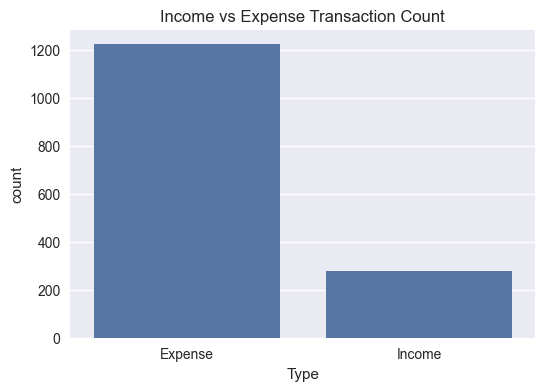

Total Income: 734087.0
Total Expense: 1227194.37


In [6]:
# Income vs Expense distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=df)
plt.title("Income vs Expense Transaction Count")
plt.show()

# Total Income vs Total Expense
total_income = df[df['Type'] == 'Income']['Amount'].sum()
total_expense = df[df['Type'] == 'Expense']['Amount'].sum()

print("Total Income:", total_income)
print("Total Expense:", total_expense)

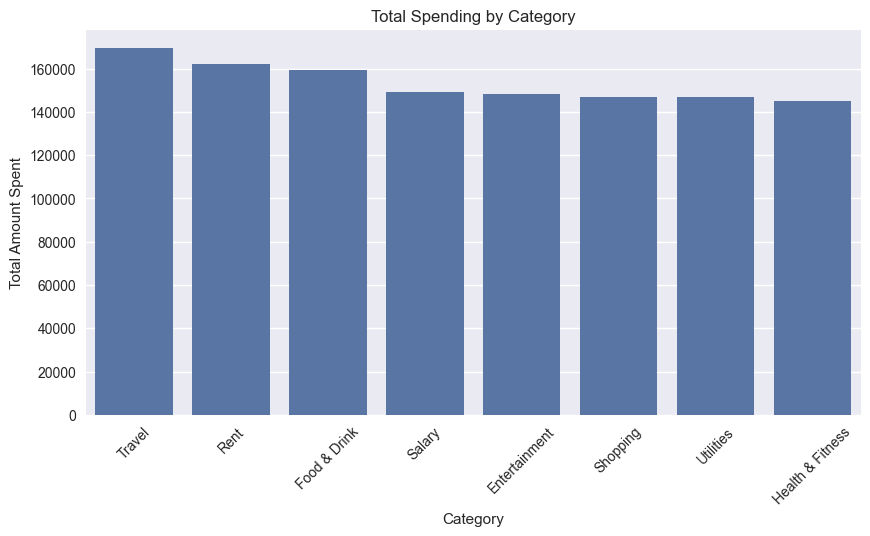

In [7]:
# Top spending categories
plt.figure(figsize=(10,5))
category_spending = df[df['Type'] == 'Expense'].groupby('Category')['Amount'].sum().sort_values(ascending=False)

sns.barplot(x=category_spending.index, y=category_spending.values)
plt.xticks(rotation=45)
plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount Spent")
plt.show()

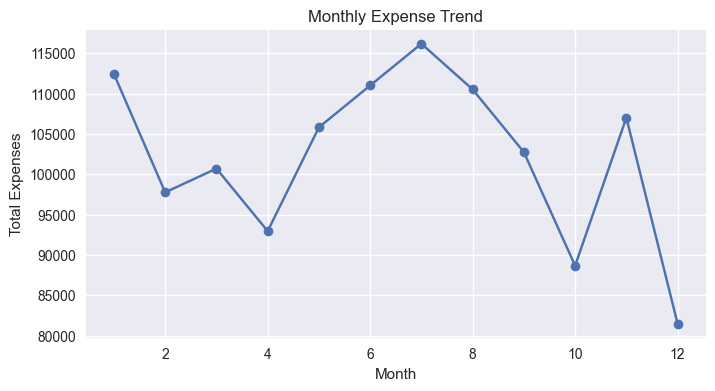

In [8]:
# Monthly expense trend
monthly_expense = df[df['Type'] == 'Expense'].groupby('Month')['Amount'].sum()

plt.figure(figsize=(8,4))
monthly_expense.plot(marker='o')
plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Total Expenses")
plt.show()

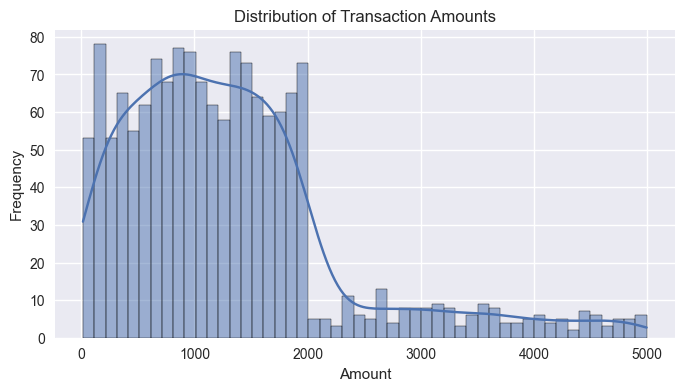

In [9]:
# Distribution of transaction amounts
plt.figure(figsize=(8,4))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()